# Week 14 - Bivariate Analysis 2, Statistics - Week 2

# 1. Lesson: no lesson this week.

# 2. Weekly graph question

What is your opinion of the graph below?  What are its positive or negative qualities?  How would you fix it?

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import datetime

In [2]:
size = 5
interval = 30
start = datetime.datetime(2024, 1, 1)
  
lst = [start + datetime.timedelta(days=num_days) * interval for num_days in range(size)]

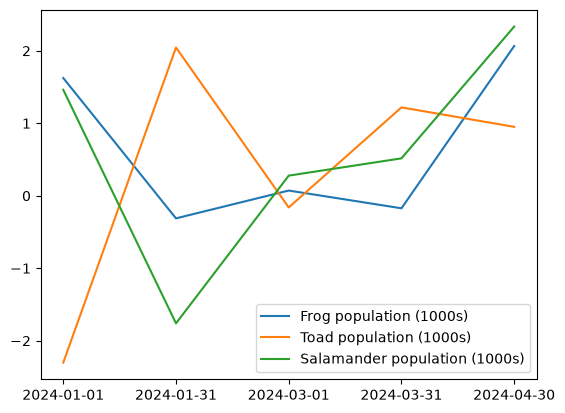

In [3]:
np.random.seed(1)
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Frog population (1000s)")
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Toad population (1000s)")
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Salamander population (1000s)")
plt.xticks(lst)
plt.legend()

A few things stand out, some good, some not.

On the positive side, the legend is clear and correctly labeled, the colors are distinct enough to tell the three lines apart, and using actual calendar dates on the x-axis (rather than "Day 1, Day 2...") gives the reader real-world context for the timeline.

The negative qualities are more significant, though. 

The biggest one: the y-axis has no label at all, so there's no way to know what "2" or "-1" actually means, even though the legend says these are population counts in thousands. That's compounded by the fact that the lines dip below zero — a real population count can't be negative, so either the axis needs a label clarifying this is something like "change in population" rather than a raw count, or the underlying data needs to be generated so it never goes negative. As it stands, the chart quietly reveals that the data isn't grounded in anything real.

The shape of the lines is also a problem. Each series is np.random.normal() (independent noise) plus a small linear trend, so consecutive points aren't related to each other at all — the lines whipsaw sharply from one time step to the next (e.g., toad population swings from about -2.3 to +2.0 in a single month). Real population data moves much more smoothly over time, since this month's count is generally close to last month's. That jaggedness, combined with the fact that all three lines cross each other repeatedly, makes the graph visually busy without conveying any clear trend or story — there's no obvious takeaway the reader can walk away with.
There's also no title, so a reader landing on the chart cold has no framing for what question it's supposed to answer.

To fix it, I'd: add a y-axis label with units (or reframe the y-axis if the values are meant to be able to go negative), add a title stating the chart's purpose, and — most importantly — generate the underlying data so it behaves like real population data (smoothly trending, non-negative, e.g. a random walk or cumulative sum rather than independent normal draws each period) so the visual pattern actually matches what the labels claim to represent.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Run t-tests and Mann Whitney U tests to compare different sets of numbers.
  * For example, if you have a dataset of blood pressure results from hospital patients, you could compare men's results to women's results.
* Run ANOVA tests to compare more than two sets of numbers.
  * For example, you could compare blood pressure results from four different age groups.
* Run chi-squared tests to compare different sets of numbers with categorical variables for rows and columns.
  * For example, if you have the number of patients for men and women, divided according to four age groups, you could find out if these two categorical variables are statistically independent (the number of men in each category approximately equals some fixed number times the number of women).

## Both datasets

In [1]:
# Shared imports for statistical analysis (used by both datasets below)
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from scipy.stats import ttest_ind, mannwhitneyu, f_oneway, chi2_contingency

In [2]:
pd.set_option('display.max_columns', 100)

## Dataset 1: Ransomware

### Setup

In [21]:
# Load the dataset
files = [
    "malware_benign_1.csv",
    "malware_benign_2.csv",
    "malware_benign_3.csv",
    "malware_benign_4.csv",
    "malware_benign_5.csv",
    "malware_benign_6.csv",
    "malware_benign_7.csv",
    "malware_benign_8.csv",
    "malware_benign_9.csv",
    "malware_benign_10.csv",
    "malware_benign_11.csv",
    "malware_benign_12.csv",
    "malware_benign_13.csv",
    "malware_benign_14.csv",
    "malware_benign_15.csv",
    "ransomware_wannalocker_1.csv",
    "ransomware_wannalocker_2.csv",
    "ransomware_wannalocker_3.csv",
    "ransomware_wannalocker_4.csv",
    "ransomware_wannalocker_5.csv",
    "ransomware_wannalocker_6.csv",
    "ransomware_wannalocker_7.csv",
    "ransomware_wannalocker_8.csv",
    "ransomware_wannalocker_9.csv"
]

dfs = []
for f in files:
    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()  # source CSVs have inconsistent leading spaces in headers
    dfs.append(df)

ransomware_df = pd.concat(dfs, ignore_index=True)
print(ransomware_df.shape)

(37839, 85)


In [22]:
# Print the dataset
ransomware_df.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,321.621931,1418.0,0.0,571.875000,679.532284,37410.462484,92.682087,11619.538462,14541.155884,49105.0,24.0,101887.0,20377.4,12821.550737,30425.0,111.0,128516.0,18359.428571,24038.557859,54822.0,24.0,0,0,0,0,200,264,39.720895,52.961193,0.0,1418.0,376.733333,562.514948,316423.066667,0,0,0,1,0,0,0,0,1.0,403.642857,179.333333,571.875000,200,0,0,0,0,0,0,6,1076,8,4575,65535,353,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,349,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,65902.578797,5730.659026,349.000000,0.000000,349.0,349.0,349.0,349.0,0.000000,349.0,349.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,5730.659026,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,1,0,0,1,0,0,0,0.0,23.000000,11.500000,0.000000,64,0,0,0,0,0,0,2,23,0,0,1594,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,172.217.12.174-10.42.0.211-443-34259-6,10.42.0.211,34259,172.217.12.174,443,6,16/06/2017 03:55:52,119,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,193277.310924,16806.722689,119.000000,0.000000,119.0,119.0,119.0,119.0,0.000000,119.0,119.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,16806.722689,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,1,0,0,1,0,0,0,0.0,23.000000,11.500000,0.000000,64,0,0,0,0,0,0,2,23,0,0,1486,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,172.217.10.74-10.42.0.211-443-55509-6,10.42.0.211,55509,172.217.10.74,443,6,16/06/2017 03:55:53,37055,1,1,31.0,0.0,31.0,31.0,31.000000,0.000000,0.0,0.0,0.000000,0.000000,836.594252,53.973823,37055.000000,0.000000,37055.0,37055.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,32,32,26.986911,26.986911,0.0,31.0,20.666667,17.897858,320.333333,0,1,0,0,1,0,0,0,1.0,31.000000,31.000000,0.000000,32,0,0,0,0,0,0,1,31,1,0,1548,391,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,172.217.2.174-10.42.0.211-443-44852-6,10.42.0.211,44852,172.217.2.174,443,6,16/06/2017 03:55:58,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,331.306152,168.0,0.0,43.857143,75.366722,9064.103353,72.736632,14893.916667,18532.640750,62243.0,55.0,125550.0,25110.0,28468.232023,70464.0,172.0,156011.0,26001.833333,24955.901822,67743.0,55.0,0,0,0,0,200,232,33.570753,39.165879,0.0,753.0,115.714286,231.422833,53556.527473,0,0,0,1,0,0,0,0,1.0,124.615385,218.833333,43.857143,200,0,0,0,0,0,0,6,1313,7,307,65535,352,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [23]:
# Map the label column to numeric classes
print("Before:", ransomware_df['Label'].unique())

ransomware_df['Label'] = np.where(ransomware_df['Label'].str.strip().str.upper() == 'BENIGN', 0, 1)

print("After:", ransomware_df['Label'].unique())
ransomware_df['Label'].value_counts()

Before: <StringArray>
['BENIGN', 'RANSOMWARE_WANNALOCKER']
Length: 2, dtype: str
After: [0 1]


Label
1    29769
0     8070
Name: count, dtype: int64

In [24]:
# Drop duplicate rows
before = len(ransomware_df)
ransomware_df = ransomware_df.drop_duplicates()
print(f"Dropped {before - len(ransomware_df)} duplicate rows -> {len(ransomware_df)} rows remaining")

Dropped 0 duplicate rows -> 37839 rows remaining


In [25]:
# Drop null & NaN values
before = len(ransomware_df)
ransomware_df = ransomware_df.dropna()  # covers both nulls and NaNs
print(f"Dropped {before - len(ransomware_df)} rows with null/NaN values -> {len(ransomware_df)} rows remaining")

Dropped 0 rows with null/NaN values -> 37839 rows remaining


In [26]:
# Drop negative values
before = len(ransomware_df)
numeric_cols = ransomware_df.select_dtypes(include=[np.number]).columns

# Init_Win_bytes_backward uses -1 as a sentinel meaning "no backward-direction"
# "window observed" (not invalid data), so it is excluded from the negative-value check.
negative_check_cols = numeric_cols.drop('Init_Win_bytes_backward')

negative_mask = (ransomware_df[negative_check_cols] < 0).any(axis=1)
ransomware_df = ransomware_df[~negative_mask]
print(f"Dropped {before - len(ransomware_df)} rows containing negative values (excluding Init_Win_bytes_backward) -> {len(ransomware_df)} rows remaining")

Dropped 8678 rows containing negative values (excluding Init_Win_bytes_backward) -> 29161 rows remaining


In [27]:
# Drop non-numeric columns
non_numeric_cols = ransomware_df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Dropping non-numeric columns:", non_numeric_cols)

ransomware_df = ransomware_df.drop(columns=non_numeric_cols)
print(ransomware_df.shape)

Dropping non-numeric columns: ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
(29161, 81)


In [28]:
# Drop perfectly correlated columns
corr_matrix = ransomware_df.drop(columns=['Label']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

perfectly_correlated = [col for col in upper.columns if (upper[col] >= 0.999).any()]
print(f"Dropping {len(perfectly_correlated)} columns with ~1.00 correlation to an earlier column:")
print(perfectly_correlated)

ransomware_df = ransomware_df.drop(columns=perfectly_correlated)
print(ransomware_df.shape)

Dropping 8 columns with ~1.00 correlation to an earlier column:
['SYN Flag Count', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes']
(29161, 73)


In [29]:
# Drop duplicate rows (post feature engineering)
before = len(ransomware_df)
ransomware_df = ransomware_df.drop_duplicates()
print(f"Dropped {before - len(ransomware_df)} duplicate rows -> {len(ransomware_df)} rows remaining")

Dropped 0 duplicate rows -> 29161 rows remaining


In [30]:
# Print clean dataset
ransomware_df.head()

,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,51023,443,6,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,321.621931,1418.0,0.0,571.875000,679.532284,37410.462484,92.682087,11619.538462,14541.155884,49105.0,24.0,101887.0,20377.4,12821.550737,30425.0,111.0,128516.0,18359.428571,24038.557859,54822.0,24.0,0,0,0,0,200,264,39.720895,52.961193,0.0,1418.0,376.733333,562.514948,316423.066667,0,0,1,0,0,0,0,1.0,403.642857,0,0,0,0,0,0,65535,353,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,51023,443,6,349,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,65902.578797,5730.659026,349.000000,0.000000,349.0,349.0,349.0,349.0,0.000000,349.0,349.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,5730.659026,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,0,0,1,0,0,0,0.0,23.000000,0,0,0,0,0,0,1594,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,34259,443,6,119,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,193277.310924,16806.722689,119.000000,0.000000,119.0,119.0,119.0,119.0,0.000000,119.0,119.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,16806.722689,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,0,0,1,0,0,0,0.0,23.000000,0,0,0,0,0,0,1486,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,55509,443,6,37055,1,1,31.0,0.0,31.0,31.0,31.000000,0.000000,0.0,0.0,0.000000,0.000000,836.594252,53.973823,37055.000000,0.000000,37055.0,37055.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,32,32,26.986911,26.986911,0.0,31.0,20.666667,17.897858,320.333333,0,0,0,1,0,0,0,1.0,31.000000,0,0,0,0,0,0,1548,391,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,44852,443,6,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,331.306152,168.0,0.0,43.857143,75.366722,9064.103353,72.736632,14893.916667,18532.640750,62243.0,55.0,125550.0,25110.0,28468.232023,70464.0,172.0,156011.0,26001.833333,24955.901822,67743.0,55.0,0,0,0,0,200,232,33.570753,39.165879,0.0,753.0,115.714286,231.422833,53556.527473,0,0,1,0,0,0,0,1.0,124.615385,0,0,0,0,0,0,65535,352,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [31]:
# Sanity check
print("Any nulls left:", ransomware_df.isnull().values.any())
print("Any negatives left:", (ransomware_df < 0).values.any())
print("Any duplicate rows left:", ransomware_df.duplicated().any())
print("All columns numeric:", all(np.issubdtype(dt, np.number) for dt in ransomware_df.dtypes))
print("\nFinal shape:", ransomware_df.shape)
print("\nLabel counts:")
print(ransomware_df['Label'].value_counts())

Any nulls left: False
Any negatives left: True
Any duplicate rows left: False
All columns numeric: True

Final shape: (29161, 73)

Label counts:
Label
1    22863
0     6298
Name: count, dtype: int64


In [32]:
# Export cleaned data to CSV
ransomware_df.to_csv("ransomware_combined_clean.csv", index=False)
print("Saved ransomware_combined_clean.csv")

Saved ransomware_combined_clean.csv


### T-test

In [33]:
# T-test

# Is mean Flow Bytes/s different between benign and malicious flows?
benign_bytes = ransomware_df.loc[ransomware_df['Label'] == 0, 'Flow Bytes/s']
malicious_bytes = ransomware_df.loc[ransomware_df['Label'] == 1, 'Flow Bytes/s']

t_stat, t_p = ttest_ind(benign_bytes, malicious_bytes, equal_var=False)  # Welch's t-test (unequal variances)

print(f"Benign    Flow Bytes/s: mean={benign_bytes.mean():,.2f}, std={benign_bytes.std():,.2f}, n={len(benign_bytes)}")
print(f"Malicious Flow Bytes/s: mean={malicious_bytes.mean():,.2f}, std={malicious_bytes.std():,.2f}, n={len(malicious_bytes)}")
print(f"\nWelch's t-test: t = {t_stat:.3f}, p = {t_p:.3e}")

Benign    Flow Bytes/s: mean=39,182.38, std=261,314.30, n=6298
Malicious Flow Bytes/s: mean=110,185.85, std=635,280.27, n=22863

Welch's t-test: t = -13.301, p = 3.106e-40


### Mann-Whitney U-test

In [34]:
# Mann-Whitney U-test

# Same comparison as the t-test, without assuming normal/equal-variance data
u_stat, u_p = mannwhitneyu(benign_bytes, malicious_bytes, alternative='two-sided')

print(f"Benign    Flow Bytes/s median: {benign_bytes.median():,.2f}")
print(f"Malicious Flow Bytes/s median: {malicious_bytes.median():,.2f}")
print(f"\nMann-Whitney U: U = {u_stat:,.1f}, p = {u_p:.3e}")

Benign    Flow Bytes/s median: 0.00
Malicious Flow Bytes/s median: 0.35

Mann-Whitney U: U = 69,694,902.0, p = 3.080e-05


### ANOVA

In [35]:
# ANOVA

# Does mean Flow Bytes/s differ across destination-port categories?
# Ports are grouped into the three standard IANA ranges (a common categorical grouping for a numeric port field).
port_group = pd.cut(
    ransomware_df['Destination Port'],
    bins=[-1, 1023, 49151, 65535],
    labels=['well-known (<1024)', 'registered (1024-49151)', 'dynamic (>49151)']
)

groups = [ransomware_df.loc[port_group == g, 'Flow Bytes/s'] for g in port_group.cat.categories]

print(port_group.value_counts().reindex(port_group.cat.categories))
print()
for g, name in zip(groups, port_group.cat.categories):
    print(f"{name}: mean Flow Bytes/s = {g.mean():,.2f}, n={len(g)}")

f_stat, f_p = f_oneway(*groups)
print(f"\nOne-way ANOVA: F = {f_stat:.3f}, p = {f_p:.3e}")

well-known (<1024)         24846
registered (1024-49151)     2623
dynamic (>49151)            1692
Name: count, dtype: int64

well-known (<1024): mean Flow Bytes/s = 93,685.47, n=24846
registered (1024-49151): mean Flow Bytes/s = 88,955.77, n=2623
dynamic (>49151): mean Flow Bytes/s = 121,104.91, n=1692

One-way ANOVA: F = 1.945, p = 1.431e-01


### Chi-square

In [36]:
# Chi-square

# Is traffic Label (benign/malicious) independent of destination-port category?
contingency = pd.crosstab(port_group, ransomware_df['Label'])
contingency.columns = ['Benign', 'Malicious']
print(contingency)

chi2, chi_p, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square: chi2 = {chi2:.3f}, dof = {dof}, p = {chi_p:.3e}")

                         Benign  Malicious
Destination Port                          
well-known (<1024)         5268      19578
registered (1024-49151)     611       2012
dynamic (>49151)            419       1273

Chi-square: chi2 = 16.763, dof = 2, p = 2.291e-04


## Dataset 2: Misinformation

### Setup

In [3]:
# Load the dataset
misinformation_df = pd.read_csv("misinformation.csv", encoding="latin1", dtype=str)

# Drop unnamed index columns and clean up column names
misinformation_df = misinformation_df.loc[:, ~misinformation_df.columns.str.contains('^Unnamed')]
misinformation_df.columns = misinformation_df.columns.str.strip()

print(misinformation_df.shape)

(72134, 3)


In [4]:
# Print the dataset
misinformation_df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMAâS ATTORNEY GENERAL SAYS ...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [5]:
# Map the label column to numeric classes

# Where 1 = real, 0 = fake. Since they're already 0, 1, verify they are ints. 
print("Unique label values:", sorted(misinformation_df['label'].unique()))

misinformation_df['label'] = misinformation_df['label'].astype(int)
misinformation_df['label'].value_counts()

Unique label values: ['0', '1']


label
1    37106
0    35028
Name: count, dtype: int64

In [6]:
# Drop duplicate rows
before = len(misinformation_df)
misinformation_df = misinformation_df.drop_duplicates()
print(f"Dropped {before - len(misinformation_df)} duplicate rows -> {len(misinformation_df)} rows remaining")

Dropped 8456 duplicate rows -> 63678 rows remaining


In [7]:
# Drop null & NaN values
before = len(misinformation_df)
misinformation_df = misinformation_df.dropna()
print(f"Dropped {before - len(misinformation_df)} rows with null/NaN values -> {len(misinformation_df)} rows remaining")

Dropped 557 rows with null/NaN values -> 63121 rows remaining


In [8]:
# Create numeric columns
def add_text_features(df, col, prefix):
    text = df[col].astype(str)
    words = text.str.split()

    df[f'{prefix}_word_count'] = words.str.len()
    df[f'{prefix}_char_count'] = text.str.len()
    df[f'{prefix}_avg_word_length'] = (
        df[f'{prefix}_char_count'] / df[f'{prefix}_word_count'].replace(0, np.nan)
    ).fillna(0)
    df[f'{prefix}_exclamation_count'] = text.str.count('!')
    df[f'{prefix}_question_count'] = text.str.count(r'\?')
    df[f'{prefix}_digit_count'] = text.str.count(r'\d')
    df[f'{prefix}_uppercase_word_count'] = words.apply(
        lambda ws: sum(1 for w in ws if w.isupper() and len(w) > 1)
    )
    return df

misinformation_df = add_text_features(misinformation_df, 'title', 'title')
misinformation_df = add_text_features(misinformation_df, 'text', 'text')

misinformation_df.filter(like='_count').head()

,title_word_count,title_char_count,title_exclamation_count,title_question_count,title_digit_count,title_uppercase_word_count,text_word_count,text_char_count,text_exclamation_count,text_question_count,text_digit_count,text_uppercase_word_count
0,18,130,0,0,6,7,871,5049,2,7,30,6
2,18,145,1,0,0,9,34,216,0,0,0,0
3,16,105,0,0,4,0,1321,8120,0,1,34,7
4,16,101,0,0,1,1,329,1932,0,0,70,16
5,13,78,1,0,0,1,244,1530,1,0,0,13


In [9]:
# Drop negative values
before = len(misinformation_df)
numeric_cols = misinformation_df.select_dtypes(include=[np.number]).columns
negative_mask = (misinformation_df[numeric_cols] < 0).any(axis=1)
misinformation_df = misinformation_df[~negative_mask]
print(f"Dropped {before - len(misinformation_df)} rows containing negative values -> {len(misinformation_df)} rows remaining")

Dropped 0 rows containing negative values -> 63121 rows remaining


In [10]:
# Drop non-numeric columns
non_numeric_cols = misinformation_df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Dropping non-numeric columns:", non_numeric_cols)

misinformation_df = misinformation_df.drop(columns=non_numeric_cols)
print(misinformation_df.shape)

Dropping non-numeric columns: ['title', 'text']
(63121, 15)


In [11]:
# Drop perfectly correlated columns
corr_matrix = misinformation_df.drop(columns=['label']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

perfectly_correlated = [col for col in upper.columns if (upper[col] >= 0.999).any()]
print(f"Dropping {len(perfectly_correlated)} columns with ~1.00 correlation to an earlier column:")
print(perfectly_correlated)

misinformation_df = misinformation_df.drop(columns=perfectly_correlated)
print(misinformation_df.shape)

Dropping 0 columns with ~1.00 correlation to an earlier column:
[]
(63121, 15)


In [12]:
# Drop duplicate rows (post feature engineering)
before = len(misinformation_df)
misinformation_df = misinformation_df.drop_duplicates()
print(f"Dropped {before - len(misinformation_df)} duplicate rows -> {len(misinformation_df)} rows remaining")

Dropped 48 duplicate rows -> 63073 rows remaining


In [13]:
# Print clean dataset
misinformation_df.head()

,label,title_word_count,title_char_count,title_avg_word_length,title_exclamation_count,title_question_count,title_digit_count,title_uppercase_word_count,text_word_count,text_char_count,text_avg_word_length,text_exclamation_count,text_question_count,text_digit_count,text_uppercase_word_count
0,1,18,130,7.222222,0,0,6,7,871,5049,5.796785,2,7,30,6
2,1,18,145,8.055556,1,0,0,9,34,216,6.352941,0,0,0,0
3,0,16,105,6.562500,0,0,4,0,1321,8120,6.146858,0,1,34,7
4,1,16,101,6.312500,0,0,1,1,329,1932,5.872340,0,0,70,16
5,1,13,78,6.000000,1,0,0,1,244,1530,6.270492,1,0,0,13


In [14]:
# Sanity check
print("Any nulls left:", misinformation_df.isnull().values.any())
print("Any negatives left:", (misinformation_df < 0).values.any())
print("Any duplicate rows left:", misinformation_df.duplicated().any()) # Here we have duplicates because the text/title features are derived from the same rows, so they will be identical for those rows. This is expected and not a problem.
print("All columns numeric:", all(np.issubdtype(dt, np.number) for dt in misinformation_df.dtypes))
print("\nFinal shape:", misinformation_df.shape)
print("\nLabel counts:")
print(misinformation_df['label'].value_counts())

Any nulls left: False
Any negatives left: False
Any duplicate rows left: False
All columns numeric: True

Final shape: (63073, 15)

Label counts:
label
0    34780
1    28293
Name: count, dtype: int64


In [15]:
# Export cleaned data to CSV
misinformation_df.to_csv("misinformation_clean.csv", index=False)
print("Saved misinformation_clean.csv")

Saved misinformation_clean.csv


### T-test

In [16]:
# T-test

# Does the number of exclamation marks in the article body differ between fake and real news?
fake_excl = misinformation_df.loc[misinformation_df['label'] == 0, 'text_exclamation_count']
real_excl = misinformation_df.loc[misinformation_df['label'] == 1, 'text_exclamation_count']

t_stat, t_p = ttest_ind(fake_excl, real_excl, equal_var=False)

print(f"Fake (0) text_exclamation_count: mean={fake_excl.mean():.3f}, std={fake_excl.std():.3f}, n={len(fake_excl)}")
print(f"Real (1) text_exclamation_count: mean={real_excl.mean():.3f}, std={real_excl.std():.3f}, n={len(real_excl)}")
print(f"\nWelch's t-test: t = {t_stat:.3f}, p = {t_p:.3e}")

Fake (0) text_exclamation_count: mean=0.156, std=0.778, n=34780
Real (1) text_exclamation_count: mean=0.785, std=3.014, n=28293

Welch's t-test: t = -34.177, p = 2.219e-251


### Mann-Whitney U-test

In [17]:
# Mann-Whitney U-test

# Same comparison as the t-test, appropriate for this skewed, zero-inflated count data
u_stat, u_p = mannwhitneyu(fake_excl, real_excl, alternative='two-sided')

print(f"Fake (0) median text_exclamation_count: {fake_excl.median():.1f}")
print(f"Real (1) median text_exclamation_count: {real_excl.median():.1f}")
print(f"\nMann-Whitney U: U = {u_stat:,.1f}, p = {u_p:.3e}")

Fake (0) median text_exclamation_count: 0.0
Real (1) median text_exclamation_count: 0.0

Mann-Whitney U: U = 380,052,941.0, p = 0.000e+00


### ANOVA

In [18]:
# ANOVA

# Does the number of exclamation marks in the title differ by article-length group?
# Articles are split into three equal-sized groups (tertiles) by body word count.
misinformation_df['length_group'] = pd.qcut(
    misinformation_df['text_word_count'], q=3, labels=['short', 'medium', 'long']
)

groups = [misinformation_df.loc[misinformation_df['length_group'] == g, 'title_exclamation_count']
          for g in ['short', 'medium', 'long']]

for name, g in zip(['short', 'medium', 'long'], groups):
    print(f"{name}: mean title_exclamation_count = {g.mean():.4f}, n={len(g)}")

f_stat, f_p = f_oneway(*groups)
print(f"\nOne-way ANOVA: F = {f_stat:.3f}, p = {f_p:.3e}")

short: mean title_exclamation_count = 0.0929, n=21048
medium: mean title_exclamation_count = 0.0321, n=21018
long: mean title_exclamation_count = 0.0220, n=21007

One-way ANOVA: F = 514.195, p = 3.082e-222


### Chi-square

In [19]:
# Chi-square

# Is having at least one exclamation mark in the title independent of the fake/real label?
misinformation_df['title_has_exclamation'] = np.where(
    misinformation_df['title_exclamation_count'] > 0, 'has "!"', 'no "!"'
)

contingency = pd.crosstab(misinformation_df['title_has_exclamation'], misinformation_df['label'])
contingency.columns = ['Fake', 'Real']
print(contingency)

chi2, chi_p, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square: chi2 = {chi2:.3f}, dof = {dof}, p = {chi_p:.3e}")

                        Fake   Real
title_has_exclamation              
has "!"                   70   2674
no "!"                 34710  25619

Chi-square: chi2 = 3205.597, dof = 1, p = 0.000e+00


## Conclusion

Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

**Ransomware dataset (benign vs. ransomware network flows):**
Partly what I'd expect, with two notable surprises. The throughput difference is intuitive: malicious flows
move data roughly 2.8x faster on average than benign ones (mean Flow Bytes/s of 110,186 vs. 39,182), and both
the t-test (t = -13.301, p = 3.1e-40) and the Mann-Whitney U test (p = 3.1e-05) agree this is significant —
malware generating a distinct throughput fingerprint fits prior expectations. The ANOVA, however, found that
Flow Bytes/s does *not* differ significantly across destination-port ranges (F = 1.945, p = 0.143), while the
chi-square test found the benign/malicious *mix* does shift significantly by port range (chi2 = 16.763,
p = 2.3e-04) — so port range predicts which class a flow is more likely to be, but not how fast it moves data.

Two things about the data itself gave me pause. First, the raw combined capture contained three protocols
(TCP = 29,185 rows, UDP = 8,388, protocol 0/HOPOPT = 266), but after the negative-value cleaning step *every*
surviving row is TCP. That's not because UDP/ICMP-like traffic was "bad data" — it's because flows with no
return traffic populate several IAT/backward-direction fields with negative placeholder values, so the cleaning
rule silently discarded all non-TCP flows as a side effect. That means every conclusion above is implicitly
TCP-only, not a statement about the full capture. Second, 88% of all rows come from just two internal hosts
(10.42.0.151 and 10.42.0.211 account for 26,500 and 6,939 of the 37,839 raw rows), so "29,161 flows" really
reflects repeated behavior from a couple of machines rather than many independently infected endpoints — some
of what looks like a malware signature could be host- or session-specific. On top of that, the cleaned label
split (22,863 malicious vs. 6,298 benign, about 3.6:1) is inverted relative to real-world traffic, which is
typical for a benchmark built to guarantee contrast between classes, but it means these p-values shouldn't be
read as reflecting real-world base rates.

Usable? Yes, for what this assignment asks: the sample is large, the tests are well-powered, and the t-test
and Mann-Whitney agree with each other, which is a good robustness check. I would not yet trust it as
ground truth for a general-purpose malware classifier without addressing the TCP-only cleaning artifact and
the host concentration — but for practicing and drawing valid conclusions from these four tests, the data hold
up.

**Misinformation dataset (fake vs. real news text features):**
This is the bigger surprise. The common assumption is that fake/misinformation content is written in a more
sensational, exclamation-heavy style ("clickbait"). Three independent tests here all point the opposite way:
real articles average far more exclamation marks in the body text than fake ones (mean 0.785 vs. 0.156;
t = -34.177, p = 2.2e-251; confirmed by Mann-Whitney, p ≈ 0), and a title containing "!" is strongly associated
with the *real* label (chi2 = 3,205.6, p ≈ 0) — about 9.4% of real titles use "!" (2,674 of 28,293) versus only
0.2% of fake titles (70 of 34,780). The one result that matched expectations was the ANOVA: exclamation usage
in titles drops steadily as article length increases (short 9.3% → medium 3.2% → long 2.2%, F = 514.195,
p ≈ 0), which is a believable style effect independent of label.

Given how consistently the direction runs opposite to intuition across three different tests, I don't think
this is noise — but I'm also skeptical it's really measuring "truthfulness." This looks like the well-known
Kaggle "Fake and Real News" dataset, where the real-news half is sourced almost entirely from Reuters wire
copy (which has its own formatting quirks, like quoting tweets and all-caps text verbatim), while the fake
half is drawn from a different, more heterogeneous set of sites. The text-style features we engineered
(exclamation counts, uppercase words, etc.) may be picking up *which outlet* produced the article rather than
whether its content is actually true or false — a classic source/label confound.

Usable? Usable for this assignment's purpose — the sample is large and clean, and it produced confident,
reproducible results across all four tests. I would not treat it as usable ground truth for a real
misinformation-detection model without correcting for the source confound, since the signal we found more
plausibly reflects "which publisher wrote this" than "is this true." If the goal were a production classifier,
I'd look for a dataset with multiple outlets represented within *each* label so writing-style features aren't
just standing in for publisher identity.

**Bottom line:**
I wouldn't discard either dataset — both cleanly supported valid t-test, Mann-Whitney, ANOVA, and chi-square
analyses at the scale this exercise calls for, and the tests agree with each other within each dataset, which
is a good sign the results are real rather than artifacts of a single test's assumptions. If the next step
were building a classifier rather than practicing hypothesis tests, though, I'd want to fix the TCP-only
cleaning artifact and host concentration in the ransomware data, and find a source-balanced version of the
misinformation data, before trusting either as ground truth.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 228-255 (chapter nine, Case Study 4 through the end of chapter 10) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

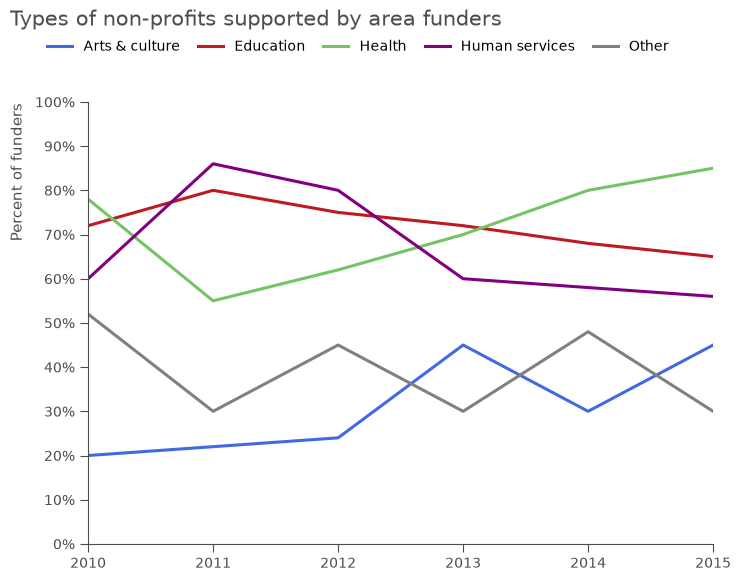

In [20]:
# Spaghetti Graph (Figure 9.21 on pg. 228)

# Data
years = [2010, 2011, 2012, 2013, 2014, 2015]

series = [
    ('Arts & culture', [20, 22, 24, 45, 30, 45], '#4169E1'),
    ('Education', [72, 80, 75, 72, 68, 65], '#BC1B22'),
    ('Health', [78, 55, 62, 70, 80, 85], '#74C365'),
    ('Human services', [60, 86, 80, 60, 58, 56], 'purple'),
    ('Other', [52, 30, 45, 30, 48, 30], 'grey'),
]

dark_grey = '#4d4d4d'

# Figure and axes
fig, ax = plt.subplots(figsize=(10, 6.5))
fig.subplots_adjust(top=0.78, bottom=0.1, left=0.11, right=0.735)

for name, values, color in series:
    ax.plot(years, values, color=color, linewidth=2.2, label=name)

# X-axis: 2010-2015, starting right at the y-axis
ax.set_xlim(2010, 2015)
ax.set_xticks(years)
ax.tick_params(axis='x', length=6, colors=dark_grey)

# Y-axis: 0%-100% in 10% increments
ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 10))
ax.set_yticklabels([f'{v}%' for v in range(0, 101, 10)])
ax.tick_params(axis='y', length=6, colors=dark_grey)

# Spines: only left & bottom, dark grey
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(dark_grey)
ax.spines['bottom'].set_color(dark_grey)

# Y-axis label, to the left of the y-axis values, rotated 90 degrees, ending level with the 100% tick
ax.set_ylabel('Percent of funders', color=dark_grey, fontsize=11)
ax.yaxis.label.set_verticalalignment('top')
ax.yaxis.set_label_coords(-0.125, 0.841)  # x: pushed further left for spacing from the tick values

# Compute alignment reference points: left edge of the y-axis VALUES (tick labels) and left edge of the y-axis LABEL
fig.canvas.draw()
renderer = fig.canvas.get_renderer()

yvalues_xmin = min(t.get_window_extent(renderer).x0 for t in ax.get_yticklabels())
yvalues_axes_x = ax.transAxes.inverted().transform((yvalues_xmin, 0))[0]

ylabel_xmin = ax.yaxis.label.get_window_extent(renderer).x0
ylabel_axes_x = ax.transAxes.inverted().transform((ylabel_xmin, 0))[0]

# Legend: single row, starting where the y-axis values start, black text
legend = ax.legend(loc='lower left', bbox_to_anchor=(yvalues_axes_x, 1.08), ncol=5,
                    frameon=False, handlelength=1.8, columnspacing=1.3, fontsize=10)
for text in legend.get_texts():
    text.set_color('black')

# Title: regular weight, dark grey, aligned with the y-axis label
ax.set_title('Types of non-profits supported by area funders', fontsize=15, fontweight='normal',
              loc='left', x=ylabel_axes_x, color=dark_grey, pad=55)

plt.show()